#**TEDS_A Cleaning**
Isra Marcu

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [9]:
TEDS_A = pd.read_csv("data/tedsa_puf_2023.csv")
TEDS_A.replace(-9, np.nan, inplace=True)

#Show All

In [10]:
pd.set_option('display.max_rows', None)

#Cleaning

In [11]:
#worst first
nan = TEDS_A.isna().sum().sort_values(ascending=False)
print(nan)
#not necessary or redundant
TEDS_A = TEDS_A.drop(columns=['CBSA2020','ADMYR', 'REGION', 'CASEID', 'DIVISION'], errors='ignore')

DETCRIM                1403567
FRSTUSE3               1398572
ROUTE3                 1388642
FREQ3                  1387356
DETNLF                 1230190
PREG                   1131055
FRSTUSE2                996944
FREQ2                   964635
ROUTE2                  963722
DAYWAIT                 872723
PRIMPAY                 867697
HLTHINS                 681477
CBSA2020                627498
PRIMINC                 563141
MARSTAT                 474164
FREQ_ATND_SELF_HELP     443359
FRSTUSE1                412027
FREQ1                   377464
ARRESTS                 376067
ROUTE1                  371466
LIVARAG                 363717
IDU                     355388
EDUC                    340515
PSOURCE                 334032
DSMCRIT                 323974
VET                     313242
SUB1                    296610
EMPLOY                  270220
PSYPROB                 229682
NOPRIOR                 186956
METHUSE                 181777
ETHNIC                  165520
SUB3    

##Drop if over 50% missing

In [12]:
miss = TEDS_A.isna().mean()
col = miss[miss <= 0.5].index
TEDS_A = TEDS_A[col]
nan2 = TEDS_A.isna().sum().sort_values(ascending=False)
print(nan2)

HLTHINS                681477
PRIMINC                563141
MARSTAT                474164
FREQ_ATND_SELF_HELP    443359
FRSTUSE1               412027
FREQ1                  377464
ARRESTS                376067
ROUTE1                 371466
LIVARAG                363717
IDU                    355388
EDUC                   340515
PSOURCE                334032
DSMCRIT                323974
VET                    313242
SUB1                   296610
EMPLOY                 270220
PSYPROB                229682
NOPRIOR                186956
METHUSE                181777
ETHNIC                 165520
SUB3                   158837
RACE                   114082
SUB2                    79820
SEX                      1227
STFIPS                      0
SERVICES                    0
ALCFLG                      0
COKEFLG                     0
MARFLG                      0
AGE                         0
HERFLG                      0
METHFLG                     0
PCPFLG                      0
OPSYNFLG  

##Duplicates

In [13]:
print(f"Duplicates: {TEDS_A.duplicated().sum()}")
TEDS_A = TEDS_A.drop_duplicates()

Duplicates: 220791


##Drop rows w missing values that we do not need...not first use because it is missing too much

In [14]:
crit = ['PSYPROB','SUB1', 'AGE', 'SEX','RACE']
TEDS_Aclean = TEDS_A.dropna(subset=crit)
#check
print(f'{TEDS_Aclean.shape[0]}, by {TEDS_Aclean.shape[1]}')
print(f'Duplicates: {TEDS_Aclean.duplicated().sum()}')

1018174, by 46
Duplicates: 0


#Rename

In [15]:
#look at codebook to see what needs to be renamed, also get column names (each one seperate so i can really see and alphabetical so it matches codebook)
#lower case first
TEDS_Aclean.columns = TEDS_Aclean.columns.str.lower()
for col in sorted(TEDS_Aclean.columns):
    print(col)
#rename
TEDS_Aclean = TEDS_Aclean.rename(columns={'alcdrug':'sub_type',
                                          'alcflg': 'alc_flag',
                                          'amphflg': 'amphetamines_flag',
                                          'arrests': 'arrests_30days',
                                          'barbflg': 'barbiturates_flag',
                                          'benzflg': 'benzos_flag',
                                          'cokeflg': 'coke_flag',
                                          'dsmcrit': 'dsm_diagnosis',
                                          'educ': 'education',
                                          'employ': 'employment',
                                          'ethnic': 'ethnicity',
                                          'freq1':'freq_sub1',
                                          'freq_atnd_self_help': 'self_help_30days',
                                          'frstuse1': 'first_use',
                                          'hallflg': 'hallucinogens_flag',
                                          'herflg': 'heroin_flag',
                                          'hlthins': 'insurance',
                                          'idu': 'iv_drug_use',
                                          'inhflg': 'inhalants_flag',
                                          'livarag':'living_arr',
                                          'marflg':'marijuana_flag',
                                          'marstat': "marital_status",
                                          'methflg': 'methadone_flag',
                                          'methuse': 'mat_use',
                                          'mthamflg': 'methamphetamine_flag',
                                          'noprior': 'prior_tx',
                                          'opsynflg': 'other_opiates_flag',
                                          'otcflg': 'otc_flag',
                                          'otherflg': "other_drug_flag",
                                          'pcpflg': 'pcp_flag',
                                          'priminc': 'income',
                                          'psource': 'referral',
                                          'psyprob': 'mental_health',
                                          'route1':'route',
                                          'sedhpflg':'sedative_flag',
                                          'services': 'treatment',
                                          'stfips': 'state',
                                          'stimflg': 'stimulants_flag',
                                          'sub1': 'sub1',
                                          'sub2': 'sub2',
                                          'sub3': 'sub3',
                                          'trnqflg': 'tranq_flag',
                                          'vet': 'veteran'
})
for col in sorted(TEDS_Aclean.columns):
    print(col)


age
alcdrug
alcflg
amphflg
arrests
barbflg
benzflg
cokeflg
dsmcrit
educ
employ
ethnic
freq1
freq_atnd_self_help
frstuse1
hallflg
herflg
hlthins
idu
inhflg
livarag
marflg
marstat
methflg
methuse
mthamflg
noprior
opsynflg
otcflg
otherflg
pcpflg
priminc
psource
psyprob
race
route1
sedhpflg
services
sex
stfips
stimflg
sub1
sub2
sub3
trnqflg
vet
age
alc_flag
amphetamines_flag
arrests_30days
barbiturates_flag
benzos_flag
coke_flag
dsm_diagnosis
education
employment
ethnicity
first_use
freq_sub1
hallucinogens_flag
heroin_flag
income
inhalants_flag
insurance
iv_drug_use
living_arr
marijuana_flag
marital_status
mat_use
mental_health
methadone_flag
methamphetamine_flag
otc_flag
other_drug_flag
other_opiates_flag
pcp_flag
prior_tx
race
referral
route
sedative_flag
self_help_30days
sex
state
stimulants_flag
sub1
sub2
sub3
sub_type
tranq_flag
treatment
veteran


##Recoding

In [16]:
#recoding process, adding them as labels so we can still have numeric for some calculations
age_map = {1: '12-14',
           2: '15-17',
           3: '18-20',
           4: '21-24',
           5: '25-29',
           6: '30-34',
           7: '35-39',
           8: '40-44',
           9: '45-49',
           10: '50-54',
           11: '55-64',
           12: '65+'
           }
TEDS_Aclean['age_label'] = TEDS_Aclean['age'].map(age_map)
age_order=list(age_map.values())
TEDS_Aclean['age_label'] = pd.Categorical(TEDS_Aclean['age_label'], categories=age_order, ordered=True)

sex_map={1:'Male',
         2: 'Female'}
TEDS_Aclean['sex_label'] = TEDS_Aclean['sex'].map(sex_map)

race_map = { 1: 'Alaska Native',
            2: 'American Indian',
            3: 'Asian/Pacific Islander',
            4: 'Black/African American',
            5: 'White',
            6: 'Asian',
            7: 'Other single race',
            8: 'Two or more races',
            9: 'Native Hawaiian/Other Pacific Islander'}
TEDS_Aclean['race_label'] = TEDS_Aclean['race'].map(race_map)

ethnicity_map = {1: 'Puerto Rican',
                 2: 'Mexican',
                 3: 'Cuban/other specific Hispanic',
                 4: 'Not Hispanic/Latino',
                 5: 'Hispanic (unspecified)'}
TEDS_Aclean['ethnicity_label'] = TEDS_Aclean['ethnicity'].map(ethnicity_map)

dsm_map = {1: 'Alcohol-induced Disorder',
           2: 'Substance-induced Disorder',
           3: 'Alcohol Intoxication',
           4: 'Alcohol Dependence',
           5: 'Opioid Dependence',
           6: 'Cocaine Dependence',
           7: 'Cannabis Dependence',
           8: 'Other Substance Dependence',
           9: 'Alcohol Abuse',
           10: 'Cannabis Abuse',
           11: 'Other Substance Abuse',
           12: 'Opioid Abuse',
           13: 'Cocaine Abuse',
           14: 'Anxiety Disorders',
           15: 'Depressive Disorders',
           16: 'Schizophrenia/Other Psychotic Disorders',
           17: 'Bipolar Disorders',
           18: 'Attention Deficit/Disruptive Behavior Disorders',
           19: 'Other Mental Health Condition'}
TEDS_Aclean['dsm_label'] = TEDS_Aclean['dsm_diagnosis'].map(dsm_map)

educ_map = {1: '≤8th Grade',
            2:'9th-11th Grade',
            3:'High School/GED',
            4:'Some College',
            5:'College Graduate'}
TEDS_Aclean['educ_label'] = TEDS_Aclean['education'].map(educ_map)
TEDS_Aclean['educ_label'] = pd.Categorical(TEDS_Aclean['educ_label'], categories=list(educ_map.values()), ordered=True)

employ_map = {1: 'Full-time',
             2: 'Part-time',
             3: 'Unemployed',
             4: 'Not in Labor Force'}
TEDS_Aclean['employment_label'] = TEDS_Aclean['employment'].map(employ_map)

first_use_map = {1: '≤11',
                 2: '12-14',
                 3: '15-17',
                 4: '18-20',
                 5: '21-24',
                 6: '25-29',
                 7: '30+'}
TEDS_Aclean['first_use_label'] = TEDS_Aclean['first_use'].map(first_use_map)
TEDS_Aclean['first_use_label'] = pd.Categorical(TEDS_Aclean['first_use_label'], categories=list(first_use_map.values()), ordered=True)

freq_sub1_map = {1: 'None in Past Month',
                 2: 'Some Use',
                 3: 'Daily Use'}
TEDS_Aclean['freq_sub1_label'] = TEDS_Aclean['freq_sub1'].map(freq_sub1_map)
TEDS_Aclean['freq_sub1_label'] = pd.Categorical(TEDS_Aclean['freq_sub1_label'], categories=list(freq_sub1_map.values()), ordered=True)

income_label = {1: 'Wages/Salary',
                2: 'Public Assistance',
                3: 'Retirement/Pension/Disability',
                4: 'Other',
                5: 'None'}
TEDS_Aclean['income_label'] = TEDS_Aclean['income'].map(income_label)

insurance_label = {1: 'Private Insurance',
                   2: 'Medicaid',
                   3: 'Medicare/Other',
                   4: 'None'}
TEDS_Aclean['insurance_label'] = TEDS_Aclean['insurance'].map(insurance_label)

living_arr_map = {1: 'Homelessness',
                  2: 'Dependent Living',
                  3: 'Independent Living'}
TEDS_Aclean['living_arr_label'] = TEDS_Aclean['living_arr'].map(living_arr_map)

marital_status_map = {1: 'Never Married',
                      2: 'Married',
                      3: 'Separated',
                      4: 'Divorced/Widowed'}
TEDS_Aclean['marital_status_label'] = TEDS_Aclean['marital_status'].map(marital_status_map)

prior_tx_label = {0: 'No Prior Treatment',
                                 1: 'One Prior Treatment',
                                 2: 'Two Prior Treatments',
                                 3: 'Three Prior Treatments',
                                 4: 'Four Prior Treatments',
                                 5: 'Five or More Prior Treatments'}
TEDS_Aclean['prior_tx_label'] = TEDS_Aclean['prior_tx'].map(prior_tx_label)
TEDS_Aclean['prior_tx_label'] = pd.Categorical(TEDS_Aclean['prior_tx_label'], categories=['No Prior Treatment', 'One Prior Treatment', 'Two Prior Treatments', 'Three Prior Treatments', 'Four Prior Treatments', 'Five or More Prior Treatments'], ordered=True)

referral_map = {1: 'Individual/Self-referral',
                2: 'Alcohol/Drug Use Care Provider',
                3: 'Other Healthcare Provider',
                4: 'School (educational)',
                5: 'Employer/EAP',
                6: 'Other Community',
                7: 'Court/Justice System/DUI/DWI'}
TEDS_Aclean['referral_label'] = TEDS_Aclean['referral'].map(referral_map)

route_label = {1: 'Oral',
               2: 'Smoking',
               3: 'Inhalation',
               4: 'Injection',
               5: 'Other'}
TEDS_Aclean['route_label'] = TEDS_Aclean['route'].map(route_label)

self_help_label = {1: 'None',
                   2: '1-3 Times',
                   3: '4-7 Times',
                   4: '8-30 Times',
                   5: 'Some/Frequency Unknown'}
TEDS_Aclean['self_help_label'] = TEDS_Aclean['self_help_30days'].map(self_help_label)
TEDS_Aclean['self_help_label'] = pd.Categorical(TEDS_Aclean['self_help_label'], categories=list(self_help_label.values()), ordered=True)

sub1_label = {1: 'None',
              2: 'Alcohol',
              3: 'Cocaine/Crack',
              4: 'Marijuana/Hashish',
              5: 'Heroin',
              6: 'Non-prescription Methadone',
              7: 'Other Opiates and Synthetics',
              8: 'PCP',
              9: 'Hallucinogens',
              10: 'Methamphetamine/Speed',
              11: 'Other Amphetamines',
              12: 'Other Stimulants',
              13: 'Benzodiazepines',
              14: 'Other Tranquilizers',
              15: 'Barbiturates',
              16: 'Other Sedatives/Hypnotics',
              17: 'Inhalants',
              18: 'OTC Medication',
              19: 'Other Drugs'}
TEDS_Aclean['sub1_label'] = TEDS_Aclean['sub1'].map(sub1_label)

sub2_label = {1: 'None',
              2: 'Alcohol',
              3: 'Cocaine/Crack',
              4: 'Marijuana/Hashish',
              5: 'Heroin',
              6: 'Non-prescription Methadone',
              7: 'Other Opiates and Synthetics',
              8: 'PCP',
              9: 'Hallucinogens',
              10: 'Methamphetamine/Speed',
              11: 'Other Amphetamines',
              12: 'Other Stimulants',
              13: 'Benzodiazepines',
              14: 'Other Tranquilizers',
              15: 'Barbiturates',
              16: 'Other Sedatives/Hypnotics',
              17: 'Inhalants',
              18: 'OTC Medication',
              19: 'Other Drugs'}
TEDS_Aclean['sub2_label'] = TEDS_Aclean['sub2'].map(sub2_label)

sub3_label = {1: 'None',
              2: 'Alcohol',
              3: 'Cocaine/Crack',
              4: 'Marijuana/Hashish',
              5: 'Heroin',
              6: 'Non-prescription Methadone',
              7: 'Other Opiates and Synthetics',
              8: 'PCP',
              9: 'Hallucinogens',
              10: 'Methamphetamine/Speed',
              11: 'Other Amphetamines',
              12: 'Other Stimulants',
              13: 'Benzodiazepines',
              14: 'Other Tranquilizers',
              15: 'Barbiturates',
              16: 'Other Sedatives/Hypnotics',
              17: 'Inhalants',
              18: 'OTC Medication',
              19: 'Other Drugs'}
TEDS_Aclean['sub3_label'] = TEDS_Aclean['sub3'].map(sub3_label)

sub_type_label = {0: 'None',
                  1: 'Alcohol Only',
                  2: 'Other Drugs Only',
                  3: 'Alcohol and Other Drugs'}
TEDS_Aclean['sub_type_label'] = TEDS_Aclean['sub_type'].map(sub_type_label)

treatment_label = {1: 'Detox - Hospital Inpatient',
                   2: 'Detox - Free Standing Residential',
                   3: 'Rehab - Hospital Inpatient',
                   4: 'Rehab - Short-Term Residential',
                   5: 'Rehab -  Long-Term Residential',
                   6: 'Ambulatory - Intensive Outpatient',
                   7: 'Ambulatory - Non-intensive Outpatient',
                   8: 'Ambulatory - Detox'}
TEDS_Aclean['treatment_label'] = TEDS_Aclean['treatment'].map(treatment_label)

arrests_30days_label = {0: 'None',
                   1: '1 Arrest',
                   2: '2+ Arrests'}
TEDS_Aclean['arrests_30days_label'] = TEDS_Aclean['arrests_30days'].map(arrests_30days_label)
TEDS_Aclean['arrests_30days_label'] = pd.Categorical(TEDS_Aclean['arrests_30days_label'], categories=list(arrests_30days_label.values()), ordered=True)

TEDS_Aclean['mat_use'] = TEDS_Aclean['mat_use'].map({1:1, 2:0})

TEDS_Aclean['mental_health'] = TEDS_Aclean['mental_health'].map({1:1, 2:0})

TEDS_Aclean['veteran'] = TEDS_Aclean['veteran'].map({1:1, 2:0})

for col in TEDS_Aclean.select_dtypes(include='object').columns:
    TEDS_Aclean[col] = TEDS_Aclean[col].astype('category')

print(TEDS_Aclean.dtypes)


state                      int64
education                float64
marital_status           float64
treatment                  int64
prior_tx                 float64
referral                 float64
arrests_30days           float64
employment               float64
mat_use                  float64
mental_health              int64
sex                      float64
veteran                  float64
living_arr               float64
dsm_diagnosis            float64
age                        int64
race                     float64
ethnicity                float64
income                   float64
sub1                     float64
sub2                     float64
sub3                     float64
route                    float64
freq_sub1                float64
first_use                float64
insurance                float64
self_help_30days         float64
alc_flag                   int64
coke_flag                  int64
marijuana_flag             int64
heroin_flag                int64
methadone_

#Transformations

In [17]:
numeric = ['age', 'sub1', 'education', 'employment', 'freq_sub1', 'prior_tx', 'arrests_30days', 'self_help_30days', 'mental_health', 'dsm_diagnosis', 'referral', 'treatment', 'income', 'insurance', 'living_arr', 'marital_status', 'route', 'first_use']
numeric =[c for c in numeric if c in TEDS_Aclean.columns]
numeric_df = TEDS_Aclean[numeric].copy()
TEDS_Aclean['prior_tx_log'] = np.log1p(TEDS_Aclean['prior_tx'])
TEDS_Aclean['arrests_30days_log'] = np.log1p(TEDS_Aclean['arrests_30days'])
numeric_filled = TEDS_Aclean[numeric].fillna(numeric_df.median())
scaler = StandardScaler()
TEDS_AcleanScaled = pd.DataFrame(scaler.fit_transform(numeric_filled), columns=numeric_filled.columns)
print(TEDS_AcleanScaled.describe().round(4).to_string())
#seperate to eval this question without impacting the data as much
TEDS_Afirstuse = TEDS_Aclean.dropna(subset=['first_use'])
#save
TEDS_Aclean.to_csv("data/tedsa_puf_2023_cleaned.csv", index=False)
TEDS_Afirstuse.to_csv("data/tedsa_puf_2023_first_use.csv", index=False)


                age          sub1     education    employment     freq_sub1      prior_tx  arrests_30days  self_help_30days  mental_health  dsm_diagnosis      referral     treatment        income     insurance    living_arr  marital_status         route     first_use
count  1.018174e+06  1.018174e+06  1.018174e+06  1.018174e+06  1.018174e+06  1.018174e+06    1.018174e+06      1.018174e+06   1.018174e+06   1.018174e+06  1.018174e+06  1.018174e+06  1.018174e+06  1.018174e+06  1.018174e+06    1.018174e+06  1.018174e+06  1.018174e+06
mean  -0.000000e+00 -0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00 -0.000000e+00   -0.000000e+00      0.000000e+00   0.000000e+00  -0.000000e+00  0.000000e+00 -0.000000e+00 -0.000000e+00 -0.000000e+00 -0.000000e+00    0.000000e+00  0.000000e+00  0.000000e+00
std    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00    1.000000e+00      1.000000e+00   1.000000e+00   1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00 

#Outlier Detection

Column 'age' has 5823 outliers.
Column 'prior_tx' has 0 outliers.
Column 'arrests_30days' has 71272 outliers.
Column 'self_help_30days' has 213273 outliers.
Column 'freq_sub1' has 0 outliers.
Column 'first_use' has 0 outliers.


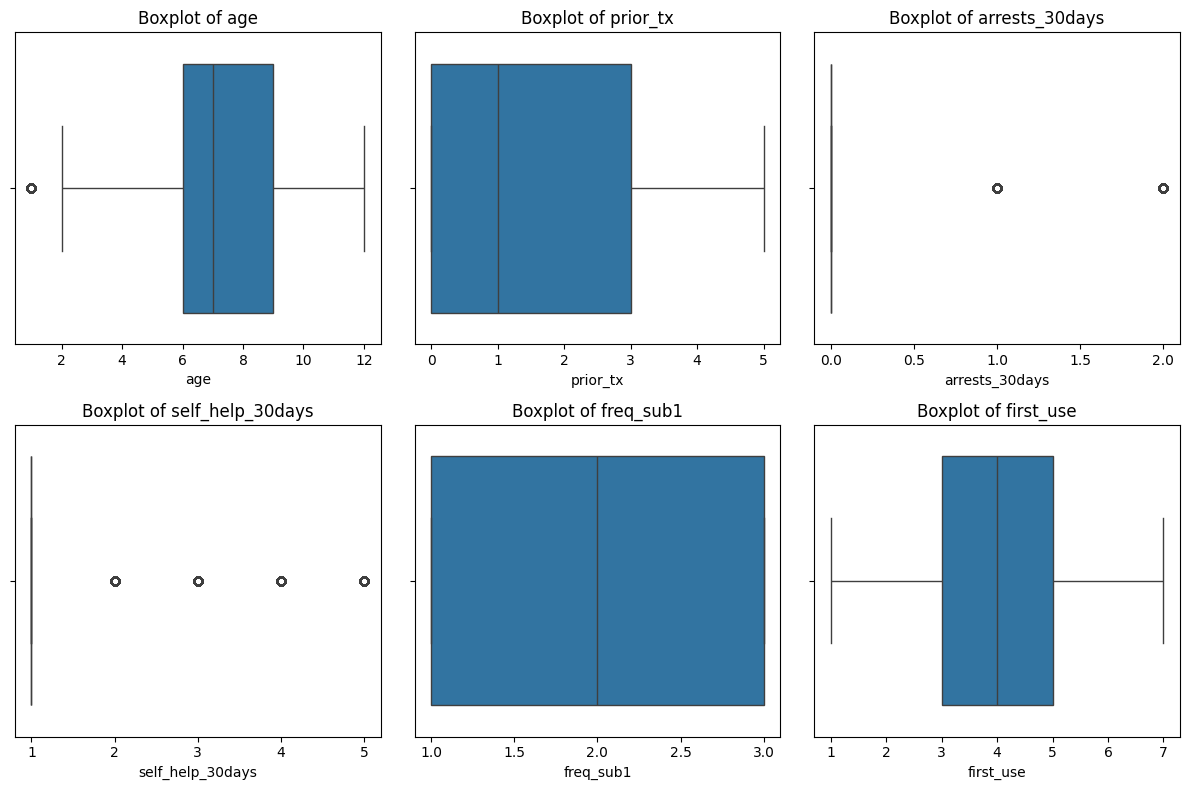

In [18]:
outlier = ['age', 'prior_tx', 'arrests_30days', 'self_help_30days', 'freq_sub1', 'first_use']
outlier = [c for c in outlier if c in TEDS_Aclean.columns]
for col in outlier:
    q1 = numeric_df[col].quantile(0.25)
    q3 = numeric_df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = numeric_df[(numeric_df[col] < lower_bound) | (numeric_df[col] > upper_bound)]
    print(f"Column '{col}' has {outliers.shape[0]} outliers.")
plt.figure(figsize=(12, 8))
for ax, col in zip(range(len(outlier)), outlier):
    plt.subplot(2, 3, ax + 1)
    sns.boxplot(x=numeric_df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

#Summary Stats

In [19]:
summary = pd.DataFrame({
    'mean': numeric_df.mean(),
    'median': numeric_df.median(),
    'std': numeric_df.std(),
    'min': numeric_df.min(),
    'max': numeric_df.max(),
    'skewness': numeric_df.skew(),
    'kurtosis': numeric_df.kurtosis(),
    'count': numeric_df.count(),
    'missing_n': numeric_df.isnull().sum(),
    'missing_pct': numeric_df.isnull().mean() * 100
})
print(summary.round(4).to_string())
for col in numeric_df:
    skew = numeric_df[col].skew()
    direction = 'right' if skew > 0 else 'left' if skew < 0 else 'none'
    print(f"Column '{col}' has skewness of {skew:.4f} and is skewed to the {direction}.")


                    mean  median     std  min   max  skewness  kurtosis    count  missing_n  missing_pct
age               7.3325     7.0  2.3795  1.0  12.0    0.0036   -0.5346  1018174          0       0.0000
sub1              4.8108     4.0  3.2639  1.0  19.0    1.1531    1.3127  1018174          0       0.0000
education         3.0025     3.0  0.9276  1.0   5.0    0.0083    0.1586   936017      82157       8.0691
employment        2.8701     3.0  1.1010  1.0   4.0   -0.6594   -0.8914   980905      37269       3.6604
freq_sub1         2.1426     2.0  0.8394  1.0   3.0   -0.2735   -1.5281   961750      56424       5.5417
prior_tx          1.8640     1.0  1.8917  0.0   5.0    0.6074   -1.1293   979040      39134       3.8435
arrests_30days    0.0856     0.0  0.3198  0.0   2.0    3.9986   16.5497   969085      49089       4.8213
self_help_30days  1.6074     1.0  1.2180  1.0   5.0    1.7714    1.5710   920648      97526       9.5785
mental_health     0.4808     0.0  0.4996  0.0   1.0    

#Correlation

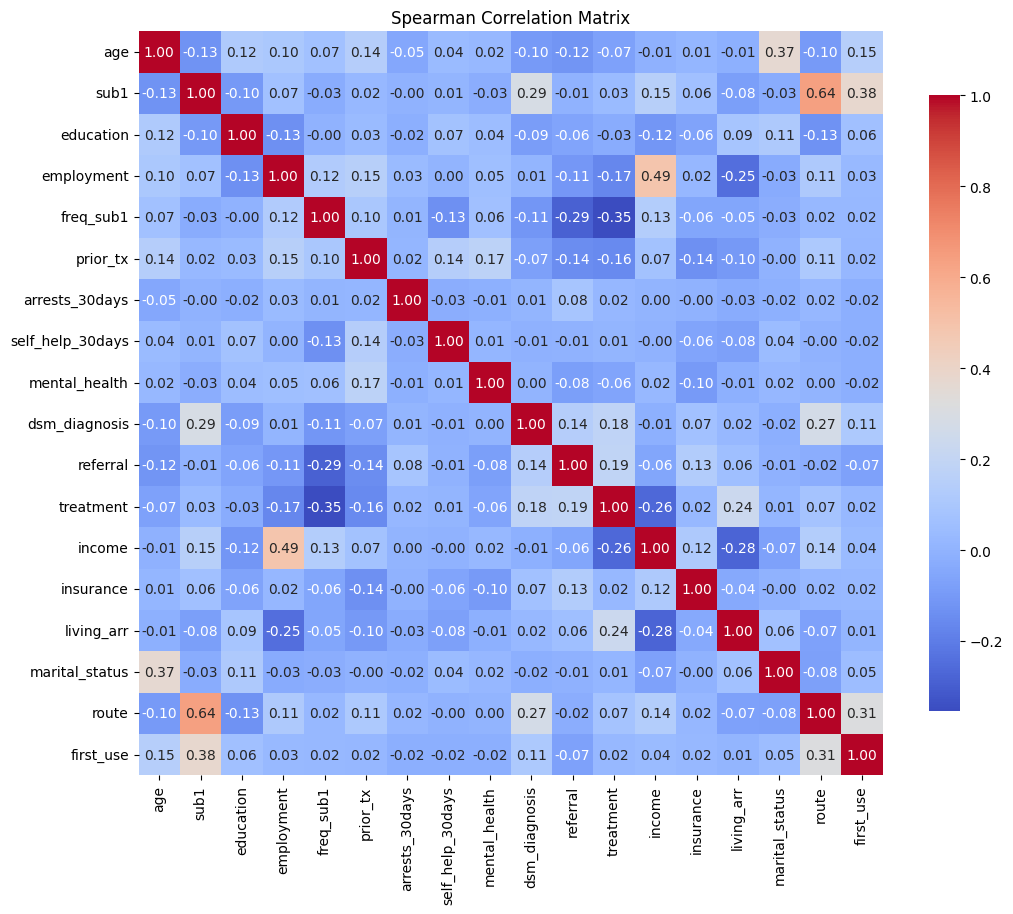

In [20]:
corr = numeric_df.corr(method='spearman')
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title('Spearman Correlation Matrix')
plt.show()

#Visualizations

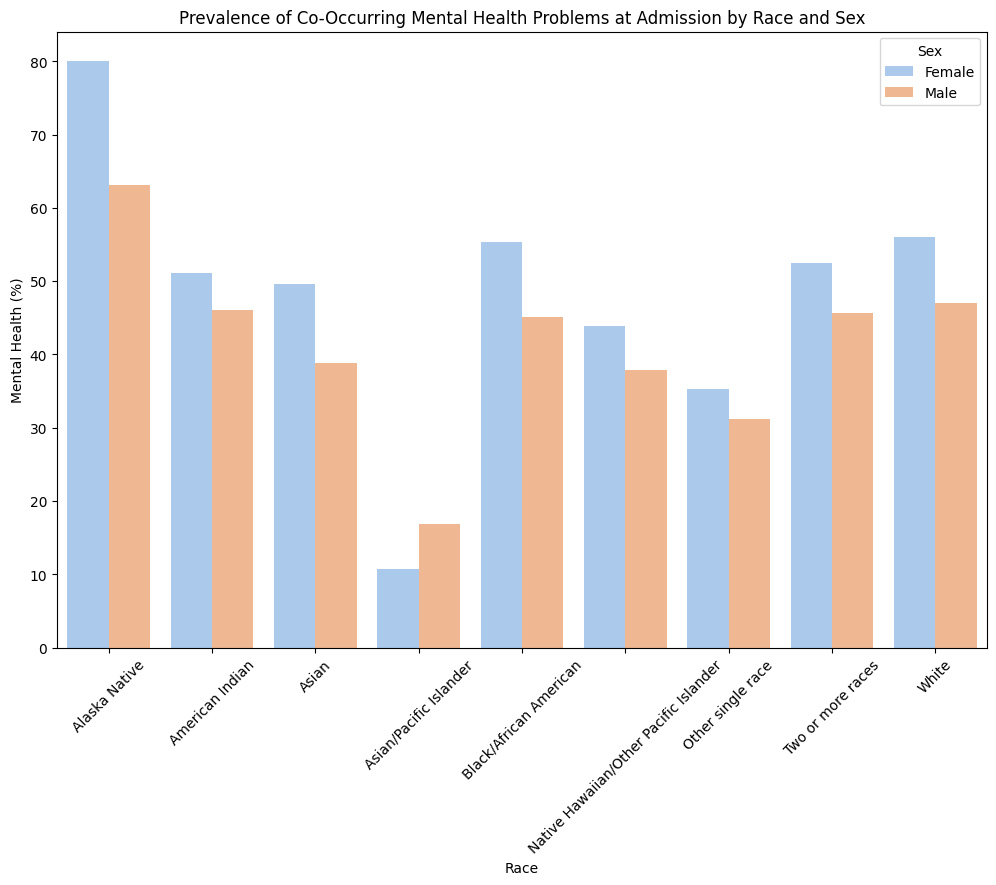

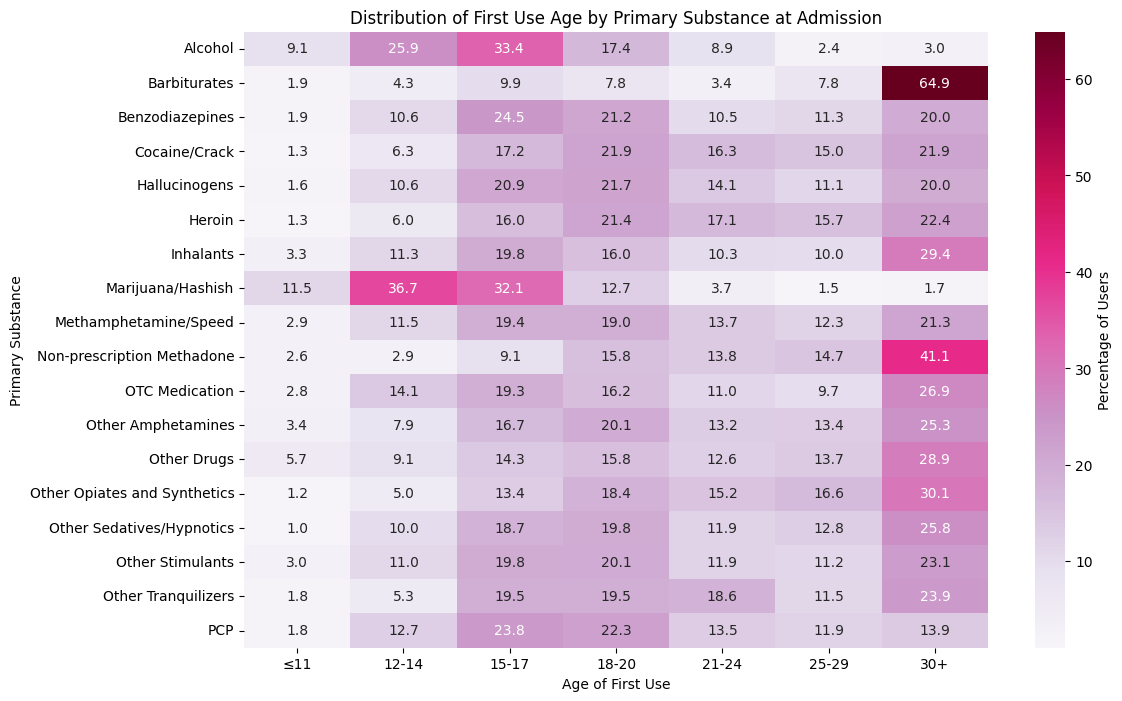

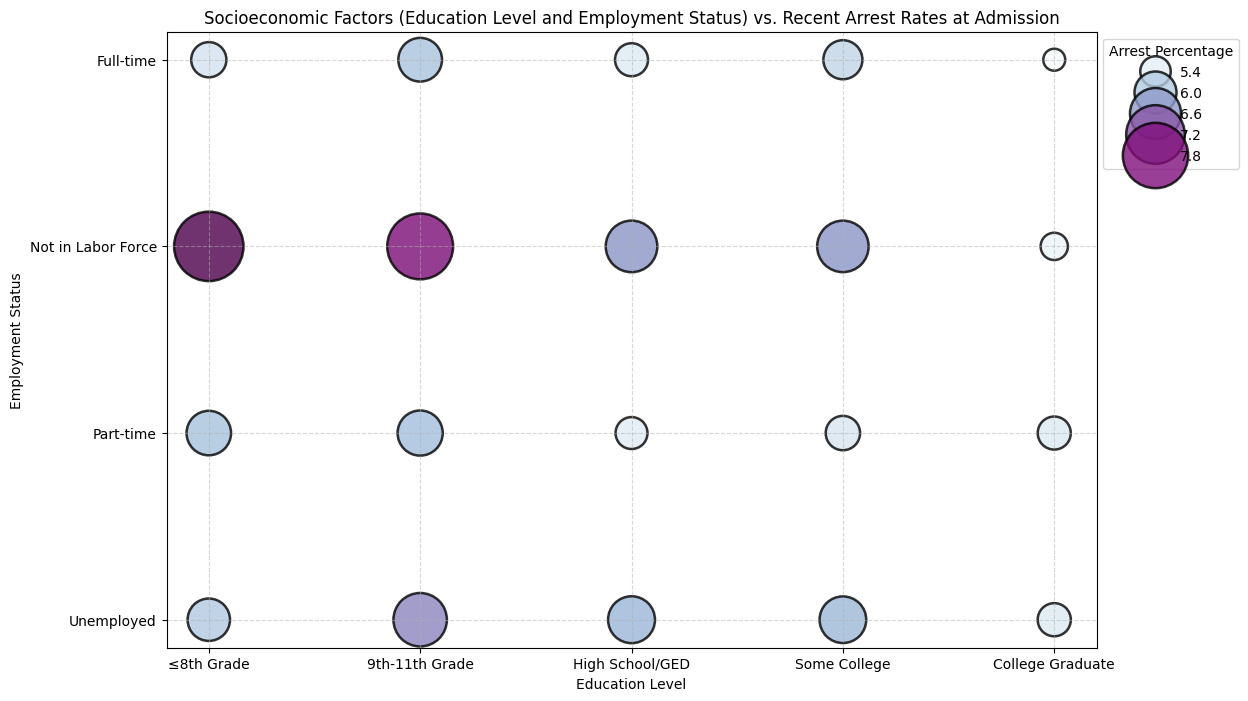

In [21]:
mh_demographics = TEDS_Aclean.groupby(['race_label', 'sex_label'], observed = True)['mental_health'].mean().reset_index()
mh_demographics['mental_health'] = mh_demographics['mental_health'] * 100
plt.figure(figsize=(12, 8))
sns.barplot(x='race_label', y='mental_health', hue='sex_label', data=mh_demographics, palette='pastel')
plt.title('Prevalence of Co-Occurring Mental Health Problems at Admission by Race and Sex')
plt.xlabel('Race')
plt.xticks(rotation=45)
plt.ylabel('Mental Health (%)')
plt.legend(title='Sex')
plt.show()

first_use_heat = pd.crosstab(TEDS_Afirstuse['sub1_label'], TEDS_Afirstuse['first_use_label'], normalize='index') * 100
first_use_heat = first_use_heat.drop(index='None', columns = 'None', errors='ignore')
plt.figure(figsize=(12,8))
sns.heatmap(first_use_heat, annot=True, fmt=".1f", cmap="PuRd", cbar_kws={'label': 'Percentage of Users'})
plt.title('Distribution of First Use Age by Primary Substance at Admission')
plt.xlabel('Age of First Use')
plt.ylabel('Primary Substance')
plt.show()

TEDS_Aclean['has_arrest'] = (TEDS_Aclean['arrests_30days'] > 0).astype(int)
socio_arrests = TEDS_Aclean.groupby(['educ_label', 'employment_label'], observed=True)['has_arrest'].mean().reset_index()
socio_arrests['arrest_pct'] = socio_arrests['has_arrest'] * 100
plt.figure(figsize=(12, 8))
sns.scatterplot(data=socio_arrests, x='educ_label', y='employment_label', size='arrest_pct', sizes=(250, 2500), hue='arrest_pct', palette='BuPu', alpha=0.8, edgecolor='black')
plt.title('Socioeconomic Factors (Education Level and Employment Status) vs. Recent Arrest Rates at Admission')
plt.xlabel('Education Level')
plt.ylabel('Employment Status')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Arrest Percentage', loc = 'upper left', bbox_to_anchor=(1, 1))
plt.show()

#Quality

In [22]:
print(f"Final dataset shape: {TEDS_Aclean.shape}")
print(f"Final dataset duplicates: {TEDS_Aclean.duplicated().sum()}")
print(f"Final dataset missing values:\n{TEDS_Aclean.isna().sum()}")
print(f"First use removed NA missing values:\n{TEDS_Afirstuse.isna().sum()}")
print(f"Final dataset data types:\n{TEDS_Aclean.dtypes}")

Final dataset shape: (1018174, 72)
Final dataset duplicates: 0
Final dataset missing values:
state                        0
education                82157
marital_status          172626
treatment                    0
prior_tx                 39134
referral                 41109
arrests_30days           49089
employment               37269
mat_use                 157861
mental_health                0
sex                          0
veteran                  42918
living_arr               89889
dsm_diagnosis           188613
age                          0
race                         0
ethnicity                17784
income                  326305
sub1                         0
sub2                     67621
sub3                    148923
route                    51151
freq_sub1                56424
first_use                88144
insurance               393695
self_help_30days         97526
alc_flag                     0
coke_flag                    0
marijuana_flag               0
heroin_f

#Q-Q plot

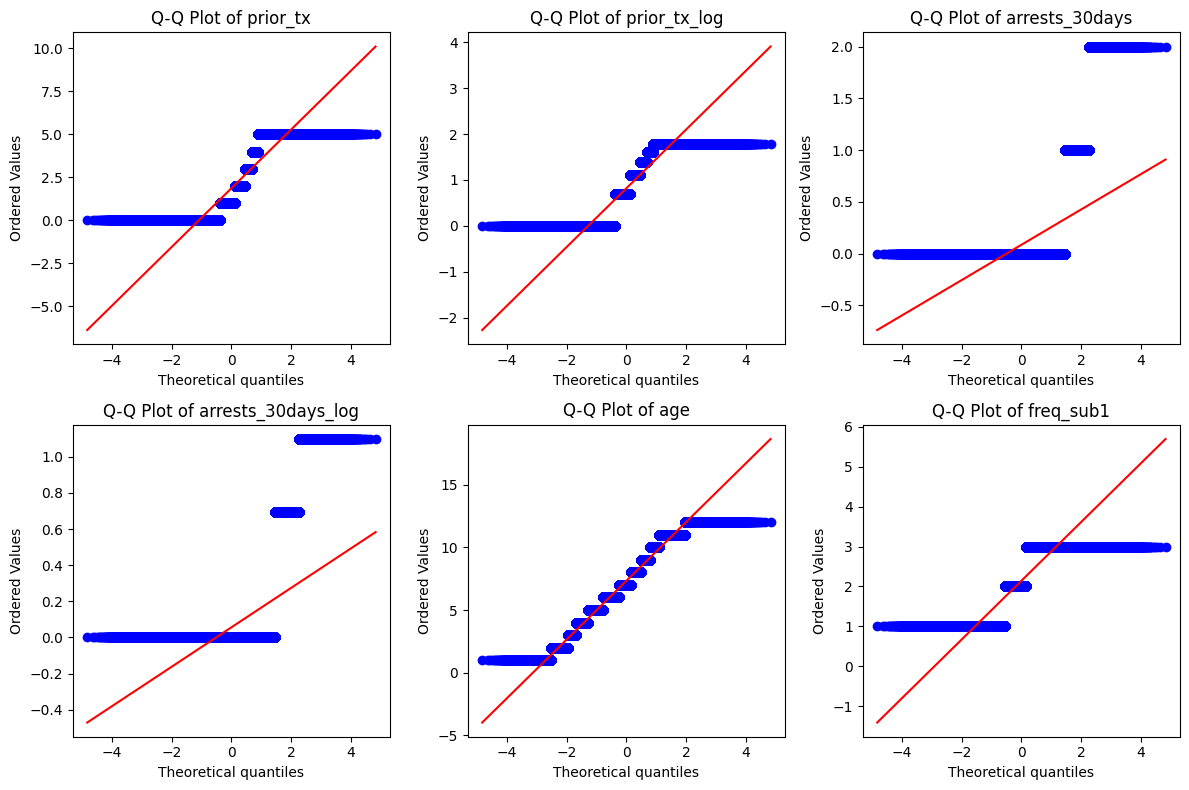

In [23]:
qq = ['prior_tx', 'prior_tx_log', 'arrests_30days', 'arrests_30days_log', 'age', 'freq_sub1']
qq = [c for c in qq if c in TEDS_Aclean.columns]
plt.figure(figsize=(12, 8))
for i, col in zip(range(len(qq)), qq):
    plt.subplot(2, 3, i + 1)
    stats.probplot(TEDS_Aclean[col].dropna(), dist="norm", plot=plt)
    plt.title(f"Q-Q Plot of {col}")
plt.tight_layout()
plt.show()